In [1]:
!pip install kagglehub -q
import kagglehub

path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
print(path)   # 파일들이 풀린 폴더 경로

Using Colab cache for faster access to the 'nasa-cmaps' dataset.
/kaggle/input/nasa-cmaps


In [2]:
import os
print(os.listdir(path))

['CMaps', '.nfs0000000059583bec000000cf']


In [3]:
import os
cmaps_path = os.path.join(path, "CMaps")
print(os.listdir(cmaps_path))

['RUL_FD002.txt', 'test_FD003.txt', 'Damage Propagation Modeling.pdf', 'readme.txt', 'train_FD003.txt', 'test_FD004.txt', 'train_FD004.txt', 'x.txt', 'test_FD002.txt', 'train_FD001.txt', 'train_FD002.txt', 'RUL_FD001.txt', 'RUL_FD004.txt', 'RUL_FD003.txt', 'test_FD001.txt']


In [4]:
import pandas as pd
train_df = pd.read_csv('/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt', sep=r"\s+", header=None)
train_df = train_df.iloc[:, :26]
test_df = pd.read_csv('/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt', sep=r"\s+", header=None)
test_df = test_df.iloc[:, :26]

col_names = ['unit', 'cycle'] + [f"op{i}" for i in range(1,4)] + [f"s{i}" for i in range(1,22)]
train_df.columns = col_names
test_df.columns = col_names

print('엔진 수:', train_df['unit'].nunique())
print('엔진 별 사이클 수:\n', train_df.groupby('unit')['cycle'].max().describe())
train_df.head()

엔진 수: 100
엔진 별 사이클 수:
 count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
train_df['RUL'] = train_df.groupby('unit')['cycle'].transform('max') - train_df['cycle']
train_df['RUL'] = train_df['RUL'].clip(upper=125)
train_df.head()

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


In [6]:
sensor_cols = [f"s{i}" for i in range(1,22)]
train_stds = train_df[sensor_cols].std().sort_values()
print(train_stds)
useless = train_stds[train_stds < 0.001].index.tolist()
print("안 쓸 센서", useless)
used_sensors = [c for c in sensor_cols if c not in useless]
print("쓸 센서:", used_sensors)

s19    0.000000e+00
s18    0.000000e+00
s16    1.556432e-14
s10    4.660829e-13
s5     3.394700e-12
s1     6.537152e-11
s6     1.388985e-03
s15    3.750504e-02
s8     7.098548e-02
s13    7.191892e-02
s21    1.082509e-01
s20    1.807464e-01
s11    2.670874e-01
s2     5.000533e-01
s12    7.375534e-01
s7     8.850923e-01
s17    1.548763e+00
s3     6.131150e+00
s4     9.000605e+00
s14    1.907618e+01
s9     2.208288e+01
dtype: float64
안 쓸 센서 ['s19', 's18', 's16', 's10', 's5', 's1']
쓸 센서: ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train_df[used_sensors] = scaler.fit_transform(train_df[used_sensors])   # train
test_df[used_sensors]  = scaler.transform(test_df[used_sensors])        # test

In [8]:
import numpy as np

def make_window(df, window, sensor_cols):
  X_list, y_list = [], []
  for unit_id in df['unit'].unique():
    eng = df[df['unit'] == unit_id]
    sensors = eng[sensor_cols].values
    ruls = eng['RUL'].values
    for start in range(len(eng) - window + 1):
      X_list.append(sensors[start : start + window])
      y_list.append(ruls[start + window - 1])
  return np.array(X_list), np.array(y_list)

X_tr, y_tr = make_window(train_df, 30, used_sensors)
print(X_tr.shape, y_tr.shape)

(17731, 30, 15) (17731,)


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RULCNN(nn.Module):
  def __init__(self, num_sensors):
    super().__init__()
    self.conv1 = nn.Conv1d(num_sensors, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
    self.pool = nn.AdaptiveAvgPool1d(1)
    self.fc = nn.Linear(64, 1)

  def forward(self, x):
    x = x.permute(0, 2, 1)
    x = F.relu(self.conv1(x))
    x = F.relu(self.conv2(x))
    x = self.pool(x).squeeze(-1)
    return self.fc(x)

In [10]:
class RULLSTM(nn.Module):
  def __init__(self, num_sensors, hidden=64):
    super().__init__()
    self.lstm = nn.LSTM(input_size=num_sensors, hidden_size=hidden, batch_first=True)
    self.fc = nn.Linear(hidden, 1)

  def forward(self, x):
    out, (h_n, c_n) = self.lstm(x)
    last = out[:, -1, :]
    return self.fc(last)

In [11]:
import numpy as np

units = train_df['unit'].unique()
rng = np.random.RandomState(42); rng.shuffle(units)
n_val = int(0.2 * len(units))
val_units, train_units = set(units[:n_val]), set(units[n_val:])

train_part = train_df[train_df['unit'].isin(train_units)]
val_part = train_df[train_df['unit'].isin(val_units)]

X_tr, y_tr = make_window(train_part, window=30, sensor_cols=used_sensors)
X_val, y_val = make_window(val_part, window=30, sensor_cols=used_sensors)


In [23]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).view(-1,1)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

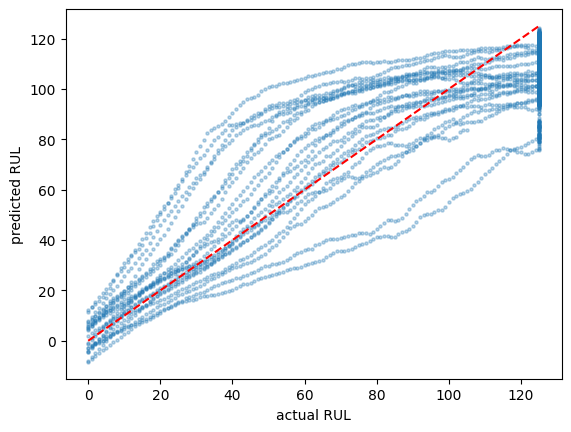

epich20: train_loss=108081.65625


In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RULCNN(num_sensors=len(used_sensors)).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
  model.train()
  train_loss = 0.0
  for Xb, yb in train_loader:
    Xb, yb = Xb.to(device), yb.to(device)
    optimizer.zero_grad()
    pred = model(Xb)
    loss = loss_fn(pred, yb)
    loss.backward()
    optimizer.step()
    train_loss += loss

import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    val_pred = model(X_val_t).cpu().numpy().ravel()

plt.scatter(y_val, val_pred, alpha=0.3, s=5)
plt.plot([0, 125], [0, 125], "r--")
plt.xlabel("actual RUL")
plt.ylabel("predicted RUL")
plt.show()
print(f"epich{epoch+1}: train_loss={train_loss}")



In [35]:
import numpy as np, torch
from torch.utils.data import TensorDataset, DataLoader

units = train_df['unit'].unique()
rng = np.random.RandomState(42); rng.shuffle(units)
n_val = int(0.2 * len(units))
val_units, train_units = set(units[:n_val]), set(units[n_val:])
train_part = train_df[train_df['unit'].isin(train_units)]
val_part = train_df[train_df['unit'].isin(val_units)]
X_tr, y_tr = make_window(train_part, 30, used_sensors)
X_val, y_val = make_window(val_part, 30, used_sensors)
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).view(-1,1)
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

In [39]:
import torch.nn as nn, torch.nn.functional as F

class RULCNN(nn.Module):
  def __init__(self, num_sensors):
    super().__init__()
    self.conv1 = nn.Conv1d(num_sensors, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
    self.pool = nn.AdaptiveAvgPool1d(1)
    self.fc = nn.Linear(64,1)
  def forward(self, x):
    x = x.permute(0, 2, 1)
    x = F.relu(self.conv1(x))
    x = F.relu(self.conv2(x))
    x = self.pool(x).squeeze(-1)
    return self.fc(x)

In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RULLSTM(num_sensors=len(used_sensors)).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [44]:
for epoch in range(20):
  model.train()
  for Xb, yb in train_loader:
    Xb, yb = Xb.to(device), yb.to(device)
    optimizer.zero_grad()
    pred = model(Xb)
    loss = loss_fn(pred, yb)
    loss.backward()
    optimizer.step()

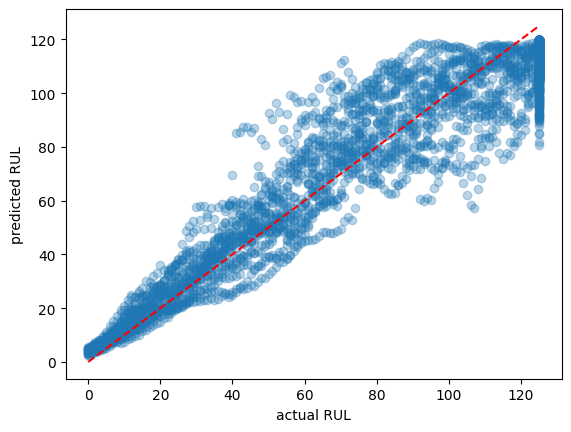

epich20: train_loss=108081.65625


In [46]:
model.eval()
with torch.no_grad():
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    val_pred = model(X_val_t).cpu().numpy().ravel()

plt.scatter(y_val, val_pred, alpha=0.3)
plt.plot([0, 125], [0, 125], "r--")
plt.xlabel("actual RUL")
plt.ylabel("predicted RUL")
plt.show()
print(f"epich{epoch+1}: train_loss={train_loss}")

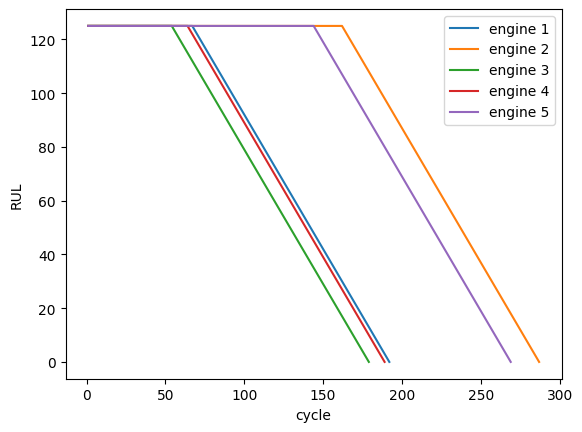

In [48]:
import matplotlib.pyplot as plt
for unit_id in [1, 2, 3, 4, 5]:
    one = train_df[train_df['unit'] == unit_id]
    plt.plot(one['cycle'], one['RUL'], label=f"engine {unit_id}")

plt.xlabel("cycle")
plt.ylabel("RUL")
plt.legend()
plt.show()